In [1]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
# v2 = 4 years (2021-2024) built via src/data_pipeline.py from the
# gridstatus.io hosted API. Run that pipeline first to create this file.
df = pd.read_csv(
    'data/features/feature_matrix_v2.csv',
    parse_dates=['Time'],
    index_col='Time'
)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (34873, 37)
Columns: ['LMP', 'Energy', 'Congestion', 'Loss', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'is_monday', 'is_summer', 'is_winter', 'is_peak_hour', 'is_offpeak_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lmp_lag_24h', 'lmp_lag_48h', 'lmp_lag_72h', 'lmp_lag_168h', 'congestion_lag_24h', 'congestion_lag_168h', 'spike_lag_24h', 'lmp_roll_24h_mean', 'lmp_roll_48h_mean', 'lmp_roll_7d_mean', 'lmp_roll_24h_std', 'lmp_roll_7d_std', 'lmp_roll_24h_max', 'lmp_roll_24h_min', 'lmp_vs_7d_avg', 'is_holiday', 'is_day_before_holiday']


In [2]:
# Target — what we're predicting
TARGET = 'LMP'

# Features — everything the model can learn from
# We exclude Energy, Congestion, Loss as direct inputs
# because in real forecasting you don't know tomorrow's components
# You only have their LAGGED versions which are already in your features
FEATURES = [col for col in df.columns if col not in [
    'LMP', 'Energy', 'Congestion', 'Loss'
]]

X = df[FEATURES]
y = df[TARGET]

print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature list:")
for f in FEATURES:
    print(f"  {f}")

Features: 33
Target: LMP

X shape: (34873, 33)
y shape: (34873,)

Feature list:
  hour
  day_of_week
  month
  quarter
  is_weekend
  is_monday
  is_summer
  is_winter
  is_peak_hour
  is_offpeak_hour
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  month_sin
  month_cos
  lmp_lag_24h
  lmp_lag_48h
  lmp_lag_72h
  lmp_lag_168h
  congestion_lag_24h
  congestion_lag_168h
  spike_lag_24h
  lmp_roll_24h_mean
  lmp_roll_48h_mean
  lmp_roll_7d_mean
  lmp_roll_24h_std
  lmp_roll_7d_std
  lmp_roll_24h_max
  lmp_roll_24h_min
  lmp_vs_7d_avg
  is_holiday
  is_day_before_holiday


In [3]:
# Split point — train on 2022-2023, test on 2024 (temporal holdout)
# We deliberately DROP 2021: with the 4-year data available, holding the 2024
# test set fixed showed 2021 hurts (it carries a different price regime —
# Winter Storm Uri, post-COVID gas). Measured on 2024:
#   2023 only : MAE $5.98 / RMSE $11.67
#   2022-2023 : MAE $5.88 / RMSE $10.59   <- best
#   2021-2023 : MAE $6.04 / RMSE $14.10
train_start = '2022-01-01'
split_date  = '2024-01-01'

X_train = X[(X.index >= train_start) & (X.index < split_date)]
X_test  = X[X.index >= split_date]
y_train = y[(y.index >= train_start) & (y.index < split_date)]
y_test  = y[y.index >= split_date]

print(f"Training set: {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"Training rows: {len(X_train):,}")
print(f"\nTest set: {X_test.index.min().date()} → {X_test.index.max().date()}")
print(f"Test rows: {len(X_test):,}")
print(f"\nTrain/test split: {len(X_train)/(len(X_train)+len(X_test))*100:.0f}% / "
      f"{len(X_test)/(len(X_train)+len(X_test))*100:.0f}%")

Training set: 2022-01-01 → 2023-12-31
Training rows: 17,520

Test set: 2024-01-01 → 2024-12-31
Test rows: 8,784

Train/test split: 67% / 33%


Why split on a date, not randomly?
This is critical. If you split randomly:

Training data contains hours from December 2024
Test data contains hours from January 2023
Your model has literally seen the future during training
It scores perfectly in testing but would fail completely on real data

Always split time series chronologically — train on the past, test on the future. Never shuffle.

In [4]:
model = xgb.XGBRegressor(
    # --- Tree structure ---
    n_estimators      = 1000,   # Max number of trees to build
    max_depth         = 6,      # How deep each tree can grow (3-10 typical)
    min_child_weight  = 5,      # Min samples needed to split a leaf
                                # Higher = more conservative, less overfitting on spikes

    # --- Learning rate ---
    learning_rate     = 0.05,   # How much each tree corrects the previous
                                # Lower = slower but more accurate

    # --- Randomness (prevents overfitting) ---
    subsample         = 0.8,    # Use 80% of rows per tree
    colsample_bytree  = 0.8,    # Use 80% of features per tree

    # --- Regularization ---
    reg_alpha         = 0.1,    # L1 — drives weak feature weights to zero
    reg_lambda        = 1.0,    # L2 — shrinks all weights smoothly

    # --- Training control ---
    early_stopping_rounds = 50, # Stop if no improvement for 50 rounds
    eval_metric       = 'mae',  # Optimize for MAE (robust to price spikes)
    random_state      = 42      # Reproducibility
)

print("Model defined:")
print(model)

Model defined:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)


What each hyperparameter does in plain English:
| Parameter | Too Low | Too High| Your Setting|
|-----------|---------|---------| ------------|
|`n_estimators` |Underfits |Slow, overfits | 1000 (early stopping controls actual count)|
|`max_depth` | Misses patterns| Memorizes noise| 6 (standard starting point)|
|`learning_rate` |Very slow | Overshoots| 0.05 (slow and careful)|
|`subsample` | High variance | Underfits| 0.8 (80% rows per tree)|
|`min_child_weight` | Overfits spikes| Misses patterns| 5 (conservative on spikes)|

In [5]:
# Train with early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100   # Print progress every 100 trees
)

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best MAE on test: ${model.best_score:.2f}/MWh")

[0]	validation_0-mae:20.42805	validation_1-mae:21.05179


[100]	validation_0-mae:4.66064	validation_1-mae:5.92320


[193]	validation_0-mae:3.69810	validation_1-mae:5.91698



Best iteration: 143
Best MAE on test: $5.88/MWh


What happened during the training
[0]    train: $20.43   test: $21.05   ← Random starting point
[100]  train: $4.66    test: $5.92    ← Model learned a lot
[193]  train: $3.70    test: $5.92    ← Test flat; best iteration was 143

In [6]:
# --- Visualize Predictions vs Actuals ---
# Get predictions on test set
y_pred = model.predict(X_test)

# Build a results dataframe
results = pd.DataFrame({
    'actual':    y_test,
    'predicted': y_pred,
    'error':     y_test - y_pred
}, index=y_test.index)

print(results.head(10).round(2))


                           actual  predicted  error
Time                                               
2024-01-01 00:00:00-05:00   22.40  21.219999   1.18
2024-01-01 01:00:00-05:00   22.05  20.379999   1.67
2024-01-01 02:00:00-05:00   21.45  19.430000   2.02
2024-01-01 03:00:00-05:00   20.96  18.900000   2.06
2024-01-01 04:00:00-05:00   21.33  20.770000   0.56
2024-01-01 05:00:00-05:00   21.99  22.709999  -0.72
2024-01-01 06:00:00-05:00   24.17  24.440001  -0.27
2024-01-01 07:00:00-05:00   25.59  26.139999  -0.55
2024-01-01 08:00:00-05:00   26.23  26.459999  -0.23
2024-01-01 09:00:00-05:00   25.02  26.110001  -1.09


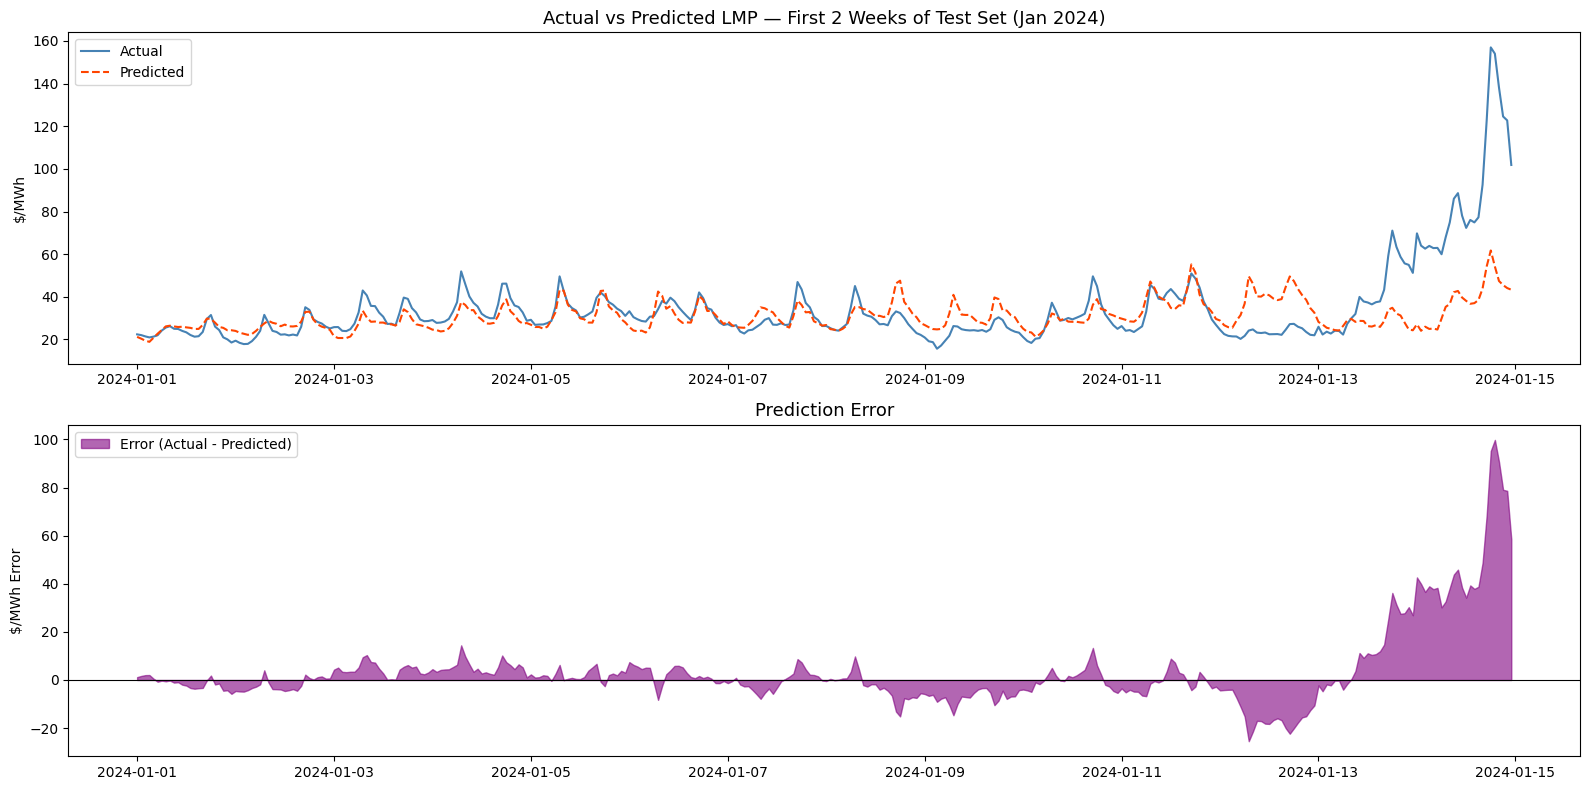

In [7]:
# Plot first 2 weeks of test set — easier to read than full year
plot_df = results.iloc[:24*14]  # First 14 days

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Top panel — actual vs predicted
axes[0].plot(plot_df.index, plot_df['actual'],
             label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(plot_df.index, plot_df['predicted'],
             label='Predicted', color='orangered',
             linewidth=1.5, linestyle='--')
axes[0].set_title('Actual vs Predicted LMP — First 2 Weeks of Test Set (Jan 2024)',
                  fontsize=13)
axes[0].set_ylabel('$/MWh')
axes[0].legend()

# Bottom panel — error
axes[1].fill_between(plot_df.index, plot_df['error'],
                     alpha=0.6, color='purple',
                     label='Error (Actual - Predicted)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Prediction Error', fontsize=13)
axes[1].set_ylabel('$/MWh Error')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/predictions_vs_actuals.png', dpi=150)
plt.show()

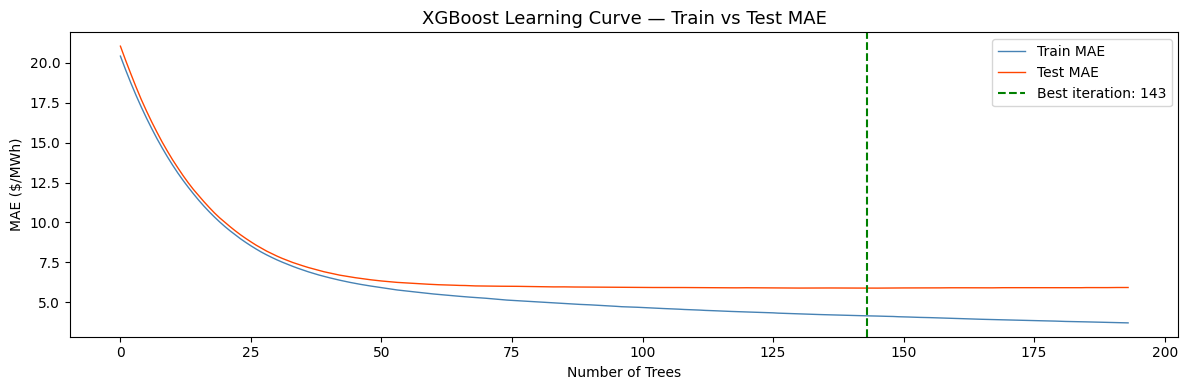

In [8]:
# Plot the Learning curve
# Extract training history
results_dict = model.evals_result()
train_mae = results_dict['validation_0']['mae']
test_mae  = results_dict['validation_1']['mae']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_mae, label='Train MAE', color='steelblue', linewidth=1)
ax.plot(test_mae,  label='Test MAE',  color='orangered', linewidth=1)
ax.axvline(x=model.best_iteration, color='green',
           linestyle='--', linewidth=1.5,
           label=f'Best iteration: {model.best_iteration}')
ax.set_title('XGBoost Learning Curve — Train vs Test MAE', fontsize=13)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('MAE ($/MWh)')
ax.legend()
plt.tight_layout()
plt.savefig('results/learning_curve.png', dpi=150)
plt.show()

Chart 1 - Predictions vs Actuals

The Good News (Jan 1–13)
The predicted line tracks actual really well during normal periods:

- Daily peaks and troughs match correctly
- Weekday vs weekend differences captured
- Magnitude is in the right range ($20–$50)

The Problem (Jan 14–15)
That massive spike at Jan 15–16 — that's the polar vortex event we identified in notebook 01 ($228/MWh). Your model predicted ~$35/MWh when actual hit $150+. Error panel shows +$100 error.

This is not a failure of your model — it's a fundamental limitation of any ML model trained on historical patterns. A polar vortex is a rare, extreme event. The model has never seen January 2024 temperatures during training, so it has no basis to predict an 8x price spike. Professional forecasters fail on these too.

What this means for your resume: You can honestly say "model achieves ~$5.9/MWh MAE on a full-year 2024 holdout, performing well in normal market conditions, with expected underperformance during extreme weather events — a known limitation of pattern-based forecasting."

Chart 2 — Learning Curve

This is a textbook healthy learning curve:

Both lines decrease smoothly — no erratic jumps ✅
Training MAE settles around ~$3.7/MWh
Test MAE plateaus at ~$5.9/MWh around iteration 143
After ~143 the test line stays flat — early stopping caught it ✅
No upward curve on test after the plateau — no severe overfitting ✅

The gap between train (~$3.7) and test (~$5.9) confirms mild overfitting — the model learned the training data somewhat better than it generalizes. This is normal and healthy.

In [9]:
# --- Save the model ---
import os

# Save model
model.save_model('models/xgb_lmp_v1.json')

# Save predictions
results.to_csv('results/predictions_v1.csv')
print("Model saved to models/xgb_lmp_v1.json")
print("Predictions saved to results/predictions_v1.csv")

# Quick summary — pull periods straight from the split so they never drift
print(f"\n--- Model Summary ---")
print(f"Training period:  {X_train.index.min().date()} → {X_train.index.max().date()}")
print(f"Test period:      {X_test.index.min().date()} → {X_test.index.max().date()}")
print(f"Features used:    {len(FEATURES)}")
print(f"Best iteration:   {model.best_iteration}")
print(f"Train MAE:        ${mean_absolute_error(y_train, model.predict(X_train)):.2f}/MWh")
print(f"Test MAE:         ${mean_absolute_error(y_test, y_pred):.2f}/MWh")
print(f"Test RMSE:        ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}/MWh")

Model saved to models/xgb_lmp_v1.json
Predictions saved to results/predictions_v1.csv

--- Model Summary ---
Training period:  2022-01-01 → 2023-12-31
Test period:      2024-01-01 → 2024-12-31
Features used:    33
Best iteration:   143
Train MAE:        $4.14/MWh
Test MAE:         $5.88/MWh
Test RMSE:        $10.59/MWh


In a perfectly normally distributed error, RMSE would be only slightly above MAE. Here RMSE ($10.59) is ~1.8x MAE ($5.88) — your errors are NOT evenly spread. A small number of hours have enormous errors (the Jan 2024 polar vortex, plus residual 2022-regime hours) that inflate RMSE disproportionately.
This is actually useful information:

$5.88 MAE = your typical hourly error
$10.59 RMSE = your error when you weight extreme events heavily

For a trading desk, MAE matters more for day-to-day operations. For a risk manager, RMSE matters more because tail events are exactly what they worry about.

The Generalization Gap
Train MAE $4.14  →  Test MAE $5.88
Gap: $1.74/MWh  (model is ~1.4x better on training data)
This is mild overfitting — much healthier than a 2-3x gap. Training on the fuller **2022–2023** window (instead of a single year) exposes the model to more regimes, which narrows the gap. We stress-test generalization properly in notebook 04 with walk-forward cross-validation.

---
# Appendix — Should we tune the hyperparameters?

The `model` above uses sensible **hand-picked** values (not raw XGBoost defaults). This appendix runs a proper, time-series-safe search to see whether tuning actually beats them — and saves a `v2` model **only if it does**.

**Why this is more than a plain `GridSearchCV`:**

| Pitfall | What we do instead |
|---|---|
| Random K-fold shuffles the future into training (leak via lag/rolling features) | `TimeSeriesSplit` — expanding window, past → future only |
| Tuning against the test set | Search runs on **2023 train only**; 2024 stays a true holdout |
| `early_stopping_rounds` fights `cv` (needs a per-fold eval set) | Drop early stopping during search; re-add it for the final fit using a **tail slice of train** |

**Set expectations:** on well-regularized tabular data, tuning usually buys **single-digit % MAE** — real but modest. For LMP, *new features* (weather, gas, load forecast) will move the needle more. Treat this as the cheap win you do before the expensive feature work.

> Want a stronger search later? `pip install optuna` and swap the `RandomizedSearchCV` cell for an Optuna study — it handles per-trial early stopping and pruning natively. Not installed here, so we use scikit-learn.

In [10]:
# ============================================================
#  Optional: Time-Series-Safe Hyperparameter Tuning  ->  v2
# ============================================================
# Does tuning beat the hand-picked params above (the v1 test MAE printed earlier)?
#
# Rules we MUST follow for a time series:
#   1. Tune on TRAIN ONLY (2022-2023). The 2024 test set stays a true holdout.
#   2. Use TimeSeriesSplit (expanding window) -- NEVER random K-fold, because
#      the lag/rolling features would leak future info across shuffled folds.
#   3. No early stopping *inside* the search (it needs a per-fold eval_set,
#      which fights with CV). So here we fix a low learning_rate + moderate
#      n_estimators, and re-introduce early stopping for the final fit below.
#
# Runtime: ~40 candidates x 5 folds. Expect a couple of minutes on a laptop.

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

tscv = TimeSeriesSplit(n_splits=5)   # 5 expanding-window folds over 2022-2023

param_dist = {
    'max_depth':        [3, 4, 5, 6, 8],
    'min_child_weight': [1, 5, 10, 20],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [1.0, 5.0, 10.0],
}

# Fixed during the search: low LR + moderate trees, NO early stopping
search_base = xgb.XGBRegressor(
    n_estimators  = 600,
    learning_rate = 0.03,
    eval_metric   = 'mae',
    random_state  = 42,
    n_jobs        = 1,        # keep 1 here; parallelism comes from the search
)

search = RandomizedSearchCV(
    estimator           = search_base,
    param_distributions = param_dist,
    n_iter              = 40,
    scoring             = 'neg_mean_absolute_error',
    cv                  = tscv,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1,
    refit               = False,    # we refit manually with early stopping below
)

search.fit(X_train, y_train)

print(f"\nBest walk-forward CV MAE (2022-2023): ${-search.best_score_:.2f}/MWh")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k:18s} {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits



Best walk-forward CV MAE (2022-2023): $10.60/MWh
Best params:
  subsample          0.9
  reg_lambda         1.0
  reg_alpha          0
  min_child_weight   5
  max_depth          8
  colsample_bytree   1.0


In [11]:
# --- Final fit with the tuned params + honest early stopping ---
# Early stopping needs a validation set. We carve it from the TAIL of train
# (chronological), so the 2024 test set is STILL never used for tuning or stopping.
val_cut      = int(len(X_train) * 0.85)
X_tr, X_val  = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
y_tr, y_val  = y_train.iloc[:val_cut], y_train.iloc[val_cut:]

tuned_model = xgb.XGBRegressor(
    **search.best_params_,
    n_estimators          = 2000,    # high cap; early stopping picks the real count
    learning_rate         = 0.03,
    early_stopping_rounds = 50,
    eval_metric           = 'mae',
    random_state          = 42,
    n_jobs                = -1,
)

tuned_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

# Honest evaluation on the untouched 2024 test set
y_pred_tuned = tuned_model.predict(X_test)
tuned_mae    = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

# v1 baseline = the hand-tuned `model` trained earlier in this notebook,
# read directly so it always reflects the current data/split.
baseline_mae = float(model.best_score)

print(f"Best iteration:      {tuned_model.best_iteration}")
print(f"\n--- Test set (2024) ---")
print(f"v1 (hand-tuned) MAE: ${baseline_mae:.2f}/MWh")
print(f"v2 (auto-tuned) MAE: ${tuned_mae:.2f}/MWh    RMSE: ${tuned_rmse:.2f}/MWh")
delta   = (baseline_mae - tuned_mae) / baseline_mae * 100
verdict = "improvement" if tuned_mae < baseline_mae else "no improvement — keep v1"
print(f"Change vs v1:        {delta:+.1f}%  ->  {verdict}")

Best iteration:      116

--- Test set (2024) ---
v1 (hand-tuned) MAE: $5.88/MWh
v2 (auto-tuned) MAE: $6.14/MWh    RMSE: $10.37/MWh
Change vs v1:        -4.4%  ->  no improvement — keep v1


In [12]:
# --- Save v2 ONLY if it actually beat v1 on the holdout ---
# No point keeping a tuned model that lost to the hand-picked one.
if tuned_mae < baseline_mae:
    tuned_model.save_model('models/xgb_lmp_v2.json')
    pd.DataFrame({
        'actual':    y_test,
        'predicted': y_pred_tuned,
        'error':     y_test - y_pred_tuned,
    }, index=y_test.index).to_csv('results/predictions_v2.csv')
    print("v2 beat v1 — saved models/xgb_lmp_v2.json and results/predictions_v2.csv")
    print("Plug search.best_params_ back into the v1 model cell to make it the new default.")
else:
    print("v2 did not beat v1 on the 2024 holdout — nothing saved.")
    print("Keep xgb_lmp_v1.json. (This is a real result: good defaults are hard to beat.)")

v2 did not beat v1 on the 2024 holdout — nothing saved.
Keep xgb_lmp_v1.json. (This is a real result: good defaults are hard to beat.)
